In [6]:
!git clone https://github.com/Iliketoeatsalmon/cv_preocr.git
%cd cv_preocr
!pip -q install opencv-python scikit-learn matplotlib seaborn

Cloning into 'cv_preocr'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 303 (delta 11), reused 292 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 1.41 MiB | 9.61 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/cv_preocr/cv_preocr


In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [9]:
DATASET_DIR = "dataset"
WRITERS = ["writer1", "writer2"]     # change to ["writer1"] if needed
LETTERS = [chr(ord('A') + i) for i in range(26)]

def list_image_paths(dataset_dir=DATASET_DIR, writers=WRITERS, letters=LETTERS):
    items = []
    for w in writers:
        for lab in letters:
            folder = os.path.join(dataset_dir, w, lab)
            if not os.path.isdir(folder):
                continue
            for fn in os.listdir(folder):
                if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    items.append((os.path.join(folder, fn), lab))
    return items

items = list_image_paths()
print("num files:", len(items))
print("example:", items[0] if len(items) else None)

num files: 191
example: ('dataset/writer1/A/A_015.png', 'A')


In [10]:
IMG_SIZE = 32

def binarize_for_cc(gray):
    gray_blur = cv2.GaussianBlur(gray, (3,3), 0)
    _, bw = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(bw) > 127:
        bw = 255 - bw
    return bw

def extract_components_as_images(path, img_size=IMG_SIZE, min_area=50):
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Cannot read image: {path}")

    bw = binarize_for_cc(gray)  # foreground=255

    kernel = np.ones((2,2), np.uint8)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)

    comps = []
    comps_x = []
    for i in range(1, num):
        x, y, w, h, area = stats[i]
        if area < min_area:
            continue

        crop = bw[y:y+h, x:x+w]

        hh, ww = crop.shape
        size = max(hh, ww)
        padded = np.zeros((size, size), dtype=np.uint8)
        y0 = (size - hh)//2
        x0 = (size - ww)//2
        padded[y0:y0+hh, x0:x0+ww] = crop

        resized = cv2.resize(padded, (img_size, img_size), interpolation=cv2.INTER_AREA)
        img01 = (resized > 0).astype(np.uint8)

        comps.append(img01)
        comps_x.append(x)

    comps = [c for _, c in sorted(zip(comps_x, comps), key=lambda t: t[0])]
    return comps

folder label: A num crops: 1


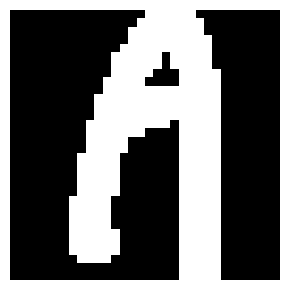

In [11]:
test_path, test_label = items[0]
crops = extract_components_as_images(test_path)

print("folder label:", test_label, "num crops:", len(crops))

plt.figure(figsize=(12,3))
for i, c in enumerate(crops[:10]):
    plt.subplot(1, min(10, len(crops)), i+1)
    plt.imshow(c, cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
def feat_flatten(img01):
    return img01.flatten().astype(np.float32)

def feat_zoning(img01, grid=4):
    h, w = img01.shape
    gh, gw = h // grid, w // grid
    feats = []
    for r in range(grid):
        for c in range(grid):
            block = img01[r*gh:(r+1)*gh, c*gw:(c+1)*gw]
            feats.append(block.mean())
    return np.array(feats, dtype=np.float32)

def feat_zoning_4x4(img01):
    return feat_zoning(img01, grid=4)

def feat_zoning_8x8(img01):
    return feat_zoning(img01, grid=8)

def feat_projection(img01):
    row_sum = img01.sum(axis=1).astype(np.float32) / IMG_SIZE
    col_sum = img01.sum(axis=0).astype(np.float32) / IMG_SIZE
    return np.concatenate([row_sum, col_sum]).astype(np.float32)

FEATURES = {
    "flatten_32x32": feat_flatten,   # 1024
    "zoning_4x4": feat_zoning_4x4,   # 16
    "zoning_8x8": feat_zoning_8x8,   # 64
    "projection_hist": feat_projection,  # 64
}

In [14]:
def build_dataset_from_components(items, feat_fn):
    X, y = [], []
    for path, lab in items:
        comps = extract_components_as_images(path)
        for img01 in comps:
            X.append(feat_fn(img01))
            y.append(lab)
    return np.vstack(X), np.array(y)

# dimension check
for name, fn in FEATURES.items():
    Xtmp, ytmp = build_dataset_from_components(items[:5], fn)
    print(name, "dim =", Xtmp.shape[1], "samples =", Xtmp.shape[0])

flatten_32x32 dim = 1024 samples = 5
zoning_4x4 dim = 16 samples = 5
zoning_8x8 dim = 64 samples = 5
projection_hist dim = 64 samples = 5


In [15]:
def evaluate_feature_components(feat_fn, k=3, test_size=0.2, random_state=42):
    X, y = build_dataset_from_components(items, feat_fn)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc, y_test, y_pred

results = {}
pred_cache = {}

for name, fn in FEATURES.items():
    acc, y_test, y_pred = evaluate_feature_components(fn, k=3)
    results[name] = acc
    pred_cache[name] = (y_test, y_pred)
    print(name, "accuracy =", acc)

results

flatten_32x32 accuracy = 0.9230769230769231
zoning_4x4 accuracy = 0.9560439560439561
zoning_8x8 accuracy = 0.967032967032967
projection_hist accuracy = 0.9560439560439561


{'flatten_32x32': 0.9230769230769231,
 'zoning_4x4': 0.9560439560439561,
 'zoning_8x8': 0.967032967032967,
 'projection_hist': 0.9560439560439561}

Best feature: zoning_8x8 acc: 0.967032967032967


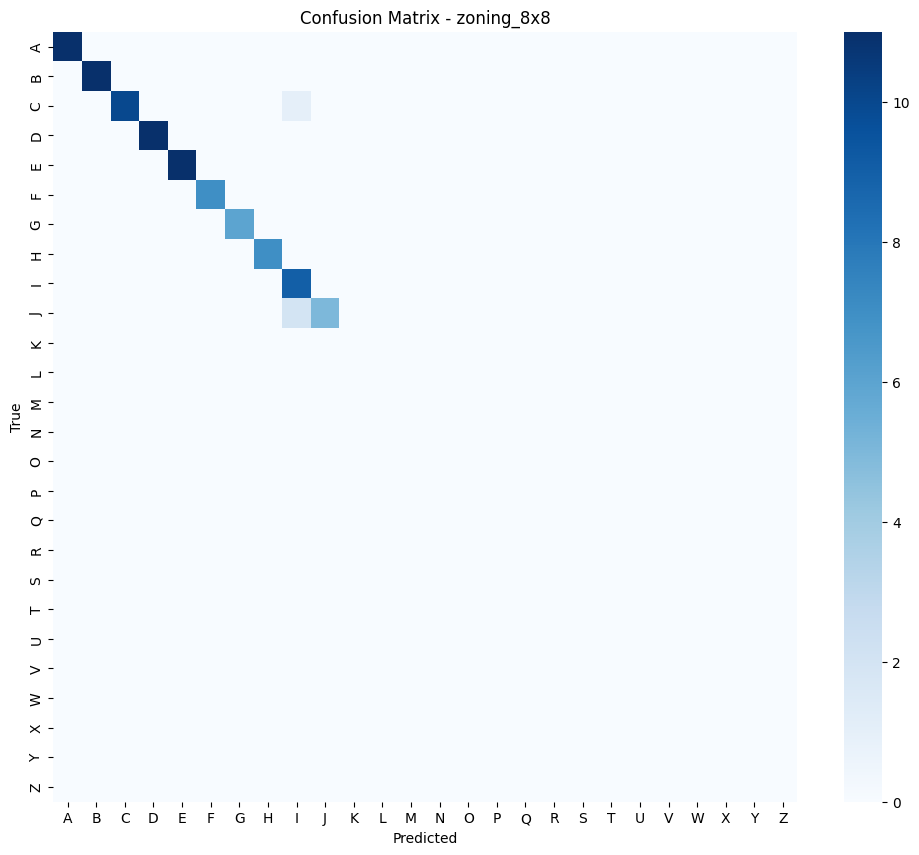

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        11
           C       1.00      0.91      0.95        11
           D       1.00      1.00      1.00        11
           E       1.00      1.00      1.00        11
           F       1.00      1.00      1.00         7
           G       1.00      1.00      1.00         6
           H       1.00      1.00      1.00         7
           I       0.75      1.00      0.86         9
           J       1.00      0.71      0.83         7

    accuracy                           0.97        91
   macro avg       0.97      0.96      0.96        91
weighted avg       0.98      0.97      0.97        91



In [17]:
best_name = max(results, key=results.get)
print("Best feature:", best_name, "acc:", results[best_name])

y_test, y_pred = pred_cache[best_name]
cm = confusion_matrix(y_test, y_pred, labels=LETTERS)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=LETTERS, yticklabels=LETTERS)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred))

In [ ]:
# 1. Clone + install: download your repo in Colab and install OpenCV + scikit-learn.
# 2. Imports: load libraries for CV, ML, and plotting.
# 3. Load paths (items): read all image files and get labels from folder names (A–Z).
# 4. Segmentation: threshold → connected components → crop each letter in the image → resize to 32×32.
# 5. Features: convert each crop to numbers using
#      Flatten (1024)
#      Zoning 4×4 (16)
#      Zoning 8×8 (64)
#      Projection (64)
# 6. Train/Test k-NN: split data, scale features, train k-NN, compare accuracy per feature type.
# 7. Confusion matrix: show which letters get confused and analyze mistakes.